# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

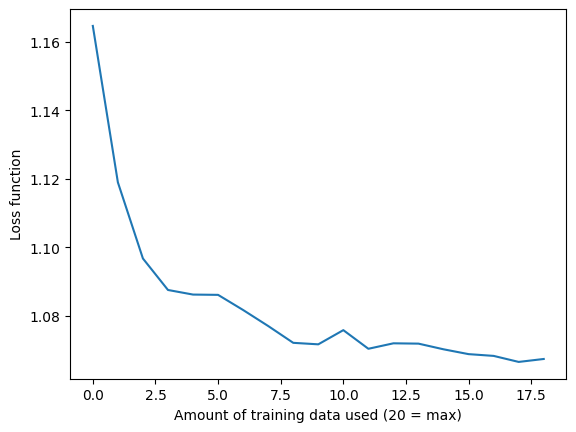

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

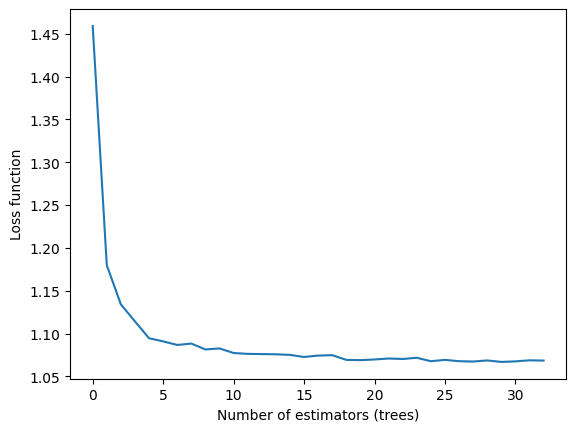

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

If I had to cut one of the plots, I would remove the Number of estimators plot. We can see past around 5 estimators, the performance does not increase much. Therefore the plot is not very informative beyond understanding that we do not need many estimators to minimize the loss.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [3]:
df = pd.read_csv('Milestone 3 EDA/hi_small_trans_cleaned.csv')
df

,Timestamp,From Bank,Account,To Bank,Account.1,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,...,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,0,3697.340000,3697.340000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0,0.010000,0.010000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,0,14675.570000,14675.570000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,0,2806.970000,2806.970000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,0,36682.970000,36682.970000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0,3107.386389,3107.386389,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0,2168.020464,2168.020464,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0,100.011894,100.011894,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0,770.280058,770.280058,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [6]:
random_state = 42

In [4]:
X = df.drop(columns='Is Laundering')
y = df['Is Laundering']

In [ ]:
from sklearn.model_selection import train_test_split

# TODO: Create balanced sample
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [9]:
from sklearn.model_selection import RepeatedKFold, cross_val_score


model = RandomForestRegressor(random_state=random_state)

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)
scores


ValueError: 
All the 25 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\ensemble\_forest.py", line 359, in fit
    X, y = validate_data(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 2971, in validate_data
    X, y = check_X_y(X, y, **check_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1368, in check_X_y
    X = check_array(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1053, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\_array_api.py", line 757, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\core\generic.py", line 2171, in __array__
    arr = np.asarray(values, dtype=dtype)
ValueError: could not convert string to float: '2022/09/09 08:05'

--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\ensemble\_forest.py", line 359, in fit
    X, y = validate_data(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 2971, in validate_data
    X, y = check_X_y(X, y, **check_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1368, in check_X_y
    X = check_array(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1053, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\_array_api.py", line 757, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\core\generic.py", line 2171, in __array__
    arr = np.asarray(values, dtype=dtype)
ValueError: could not convert string to float: '2022/09/09 01:08'

--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\ensemble\_forest.py", line 359, in fit
    X, y = validate_data(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 2971, in validate_data
    X, y = check_X_y(X, y, **check_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1368, in check_X_y
    X = check_array(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1053, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\_array_api.py", line 757, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\core\generic.py", line 2171, in __array__
    arr = np.asarray(values, dtype=dtype)
ValueError: could not convert string to float: '2022/09/07 14:23'

--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\ensemble\_forest.py", line 359, in fit
    X, y = validate_data(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 2971, in validate_data
    X, y = check_X_y(X, y, **check_params)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1368, in check_X_y
    X = check_array(
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py", line 1053, in check_array
    array = _asarray_with_order(array, order=order, dtype=dtype, xp=xp)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\_array_api.py", line 757, in _asarray_with_order
    array = numpy.asarray(array, order=order, dtype=dtype)
  File "c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\pandas\core\generic.py", line 2171, in __array__
    arr = np.asarray(values, dtype=dtype)
ValueError: could not convert string to float: '2022/09/09 21:15'


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

Text(0.5, 1.0, 'Average Retail Product Price per Year')

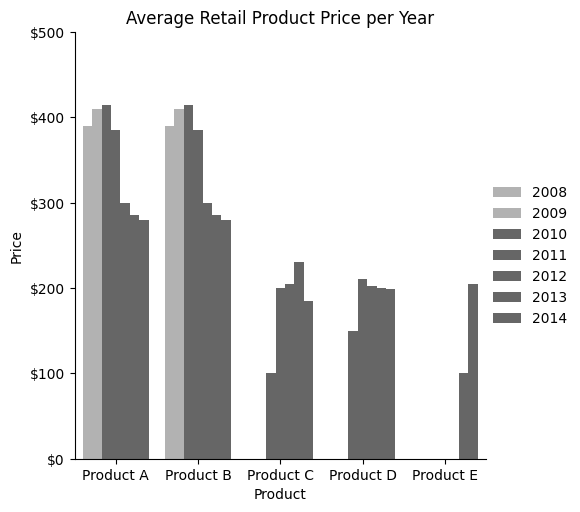

In [ ]:
# Figure 8.3 (p. 191)
import seaborn as sns
import matplotlib.ticker as tkr

products = [
    'Product A',
    'Product A',
    'Product A',
    'Product A',
    'Product A',
    'Product A',
    'Product A',
    'Product B',
    'Product B',
    'Product B',
    'Product B',
    'Product B',
    'Product B',
    'Product B',
    'Product C',
    'Product C',
    'Product C',
    'Product C',
    'Product C',
    'Product C',
    'Product C',
    'Product D',
    'Product D',
    'Product D',
    'Product D',
    'Product D',
    'Product D',
    'Product D',
    'Product E',
    'Product E',
    'Product E',
    'Product E',
    'Product E',
    'Product E',
    'Product E',
]
years = [
    # A
    '2008',
    '2009',
    '2010',
    '2011',
    '2012',
    '2013',
    '2014',
    # B
    '2008',
    '2009',
    '2010',
    '2011',
    '2012',
    '2013',
    '2014',
    # C
    '2008',
    '2009',
    '2010',
    '2011',
    '2012',
    '2013',
    '2014',
    # D
    '2008',
    '2009',
    '2010',
    '2011',
    '2012',
    '2013',
    '2014',
    # E
    '2008',
    '2009',
    '2010',
    '2011',
    '2012',
    '2013',
    '2014',
]
prices = [
    # A
    390,
    410,
    415,
    385,
    300,
    285,
    280,
    # B
    390,
    410,
    415,
    385,
    300,
    285,
    280,
    # C
    0,
    0,
    100,
    200,
    205,
    230,
    185,
    # D
    0,
    0,
    150,
    210,
    202,
    200,
    199,
    # E
    0,
    0,
    0,
    0,
    0,
    100,
    205,
]
df = pd.DataFrame({
    'Product': products,
    'Year': years,
    'Price': prices
})

# Draw a nested barplot by species and sex
colors = ["gray", "gray", "black", "black", "black", "black", "black"]

g = sns.catplot(
    data=df, kind="bar",
    x="Product", y="Price", hue="Year",
    palette=colors, alpha=.6,
)
# Apply dollar sign formatting
fmt = '${x:,.0f}' # Adds $ and comma separators
tick = tkr.StrMethodFormatter(fmt)
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(tick)

plt.ylim(None, 500) # Sets y-max to 100

g.legend.set_title("")
plt.title("Average Retail Product Price per Year")